# Validating kinGEMs Pipeline on $E. coli$ iML1515 Model

This notebook validates the metabolic flux predictions ecGEMs constructed with kinGEMs against experimental flux data. 

The experimental data comes from the study of Crown et al. (2015). It corresponds to measured metabolic fluxes using 13C metabolic flux analysis (13C-MFA). The studied organism was a W3110 strain of *E. coli*, grown on M9 media.

---
S. B. Crown, C. P. Long, and M. R. Antoniewicz, “Integrated 13 C-metabolic flux analysis of 14 parallel labeling experiments in Escherichia coli,” Metabolic Engineering, vol. 28, pp. 151–158, Jan. 2015, doi: 10.1016/j.ymben.2015.01.001.

In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Packages
import os
import sys
import pandas as pd 
import matplotlib.pyplot as plt 
import cobra 
import numpy as np 
from datetime import datetime
import cobra as cb
import random

# Add parent directory 
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import process_kcat_predictions, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.fluxomics_validation import compare_fluxomics, apply_ecomics_condition
from kinGEMs.modeling.tuning import simulated_annealing
from kinGEMs.plots import plot_flux_correlation, plot_flux_differences

# Paths
processed_data_dir = os.path.join("../data", "processed")
experimental_data_dir = os.path.join("../data", "experimental")
model_xml = os.path.join("../models", f"iML1515_GEM.xml")
processed_data_csv = os.path.join(processed_data_dir,"ecoli_iML1515","ecoli_iML1515_processed_data.csv")


c:\Users\lyachinas\miniconda3\envs\kingems\Lib\site-packages\bioservices\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-09-29 15:55:15.817 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\lyachinas\OneDrive - University of Toronto\GitHub\kinGEMs_v2


## Run optimization with regular model

Unconstrained model biomass ~0.87

Constrained model biomass ~0.029

In [2]:
# Model and data
processed_data = pd.read_csv(processed_data_csv)
model = cb.io.read_sbml_model(model_xml)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' 
enzyme_upper_bound = 0.15

In [3]:
print("=== Annotating model with kcat and GPR ===")
model = annotate_model_with_kcat_and_gpr(
    model=model,
    df=processed_data
)

=== Annotating model with kcat and GPR ===


In [4]:
# Diagnostic: Before kcat annotation
print("[Step] After annotate_model_with_kcat_and_gpr:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After annotate_model_with_kcat_and_gpr:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b3187', 'b0037', 'b3794', 'b3426', 'b3616', 'b3447', 'b2162', 'b4141', 'b1377', 'b2296']
  First 10 reaction IDs: ['SUCASPtpp', 'EX_ptrc_e', 'DADNt2pp', 'DHPPDA2', 'G6PP', 'EX_asn__L_e', 'DGK1', 'EX_glyclt_e', 'ALLTAMH2', 'XMPtex']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [5]:
print("=== Running optimization with kcat constraints ===")
(solution_value_regular, df_FBA_regular, gene_sequences_dict_regular, _)=run_optimization_with_dataframe(
    model=model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=False)

print("Biomass value: ", solution_value_regular)

=== Running optimization with kcat constraints ===
Biomass value:  0.0295987793922211


In [6]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b3187', 'b0037', 'b3794', 'b3426', 'b3616', 'b3447', 'b2162', 'b4141', 'b1377', 'b2296']
  First 10 reaction IDs: ['SUCASPtpp', 'EX_ptrc_e', 'DADNt2pp', 'DHPPDA2', 'G6PP', 'EX_asn__L_e', 'DGK1', 'EX_glyclt_e', 'ALLTAMH2', 'XMPtex']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [7]:
out_path_regular = os.path.join("../notebooks", 
                        "results", 
                        "exp_validation_results", 
                        "W3110_MD121_M9+Glu_none", 
                        "df_FBA_regular_model.csv")

df_FBA_regular.to_csv(out_path_regular, index=False)

## Run optimization with modified model

The GEM's lower bounds are modified to match the experimental uptake and secretion rates.

Unconstrained model biomass ~0.67

Constrained model biomass ~0.67

In [8]:
# Model and data
processed_data = pd.read_csv(processed_data_csv)
model = cb.io.read_sbml_model(model_xml)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' 
enzyme_upper_bound = 0.15

In [9]:
print("=== Apply medium changes to model ===")
mod_model = apply_ecomics_condition(model=model, 
                                    medium_id='MD121', 
                                    stress='none')

=== Apply medium changes to model ===
Applying M9+Glu medium
Set EX_glc__D_e lower bound to -10
Set EX_so4_e lower bound to -1.699
Set EX_o2_e lower bound to -14.49
Set EX_co2_e lower bound to 16.22


In [10]:
# Diagnostic: Before optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_model.genes))
print("  Reactions in model:", len(mod_model.reactions))
model_gene_ids = set([g.id for g in mod_model.genes])
model_rxn_ids = set([r.id for r in mod_model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b3187', 'b0037', 'b3794', 'b3426', 'b3616', 'b3447', 'b2162', 'b4141', 'b1377', 'b2296']
  First 10 reaction IDs: ['SUCASPtpp', 'EX_ptrc_e', 'DADNt2pp', 'DHPPDA2', 'G6PP', 'EX_asn__L_e', 'DGK1', 'EX_glyclt_e', 'ALLTAMH2', 'XMPtex']
  Reactions with kcat: 0
  Reactions without kcat: 2712


In [11]:
print("=== Annotating model with kcat and GPR ===")
mod_annotated_model = annotate_model_with_kcat_and_gpr(
    model=mod_model,
    df=processed_data
)


=== Annotating model with kcat and GPR ===


In [12]:
print("=== Running optimization with kcat constraints ===")
(solution_value_modified, df_FBA_modified, gene_sequences_dict_modified, _)=run_optimization_with_dataframe(
    model=mod_annotated_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=False)

print("Biomass value: ", solution_value_modified)

=== Running optimization with kcat constraints ===
WARNING (W1002): Setting Var 'v[GLYK]' to a numeric value
`-3.370776221167169e-16` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[SPODM]' to a numeric value
`-9.102799062406032e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[QMO2]' to a numeric value
`-9.102799062406033e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
Biomass value:  0.6762711828393526


In [13]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_annotated_model.genes))
print("  Reactions in model:", len(mod_annotated_model.reactions))
model_gene_ids = set([g.id for g in mod_annotated_model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_annotated_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b3187', 'b0037', 'b3794', 'b3426', 'b3616', 'b3447', 'b2162', 'b4141', 'b1377', 'b2296']
  First 10 reaction IDs: ['SUCASPtpp', 'EX_ptrc_e', 'DADNt2pp', 'DHPPDA2', 'G6PP', 'EX_asn__L_e', 'DGK1', 'EX_glyclt_e', 'ALLTAMH2', 'XMPtex']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [14]:
out_path_modified = os.path.join("../notebooks", 
                        "results", 
                        "exp_validation_results", 
                        "W3110_MD121_M9+Glu_none", 
                        "df_FBA_modified_model.csv")

df_FBA_modified.to_csv(out_path_modified, index=False)

# Simulated annealing

In [15]:
# Model and data
processed_data = pd.read_csv(processed_data_csv)
model = cb.io.read_sbml_model(model_xml)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' 
enzyme_upper_bound = 0.15

In [16]:
print("=== Apply medium changes to model ===")
mod_model = apply_ecomics_condition(model=model, 
                                    medium_id='MD121', 
                                    stress='none')

=== Apply medium changes to model ===
Applying M9+Glu medium
Set EX_glc__D_e lower bound to -10
Set EX_so4_e lower bound to -1.699
Set EX_o2_e lower bound to -14.49
Set EX_co2_e lower bound to 16.22


In [17]:
# Diagnostic: Before optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_model.genes))
print("  Reactions in model:", len(mod_model.reactions))
model_gene_ids = set([g.id for g in mod_model.genes])
model_rxn_ids = set([r.id for r in mod_model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b3187', 'b0037', 'b3794', 'b3426', 'b3616', 'b3447', 'b2162', 'b4141', 'b1377', 'b2296']
  First 10 reaction IDs: ['SUCASPtpp', 'EX_ptrc_e', 'DADNt2pp', 'DHPPDA2', 'G6PP', 'EX_asn__L_e', 'DGK1', 'EX_glyclt_e', 'ALLTAMH2', 'XMPtex']
  Reactions with kcat: 0
  Reactions without kcat: 2712


In [18]:
print("=== Annotating model with kcat and GPR ===")
mod_annotated_model = annotate_model_with_kcat_and_gpr(
    model=mod_model,
    df=processed_data
)

=== Annotating model with kcat and GPR ===


In [19]:
print("=== Running optimization with kcat constraints ===")
(solution_value_modified, df_FBA_modified, gene_sequences_dict_modified, _)=run_optimization_with_dataframe(
    model=mod_annotated_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=False)

print("Biomass value: ", solution_value_modified)

=== Running optimization with kcat constraints ===
WARNING (W1002): Setting Var 'v[GLYK]' to a numeric value
`-3.370776221167169e-16` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[SPODM]' to a numeric value
`-9.102799062406032e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[QMO2]' to a numeric value
`-9.102799062406033e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
Biomass value:  0.6762711828393526


In [20]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_annotated_model.genes))
print("  Reactions in model:", len(mod_annotated_model.reactions))
model_gene_ids = set([g.id for g in mod_annotated_model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_annotated_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b3187', 'b0037', 'b3794', 'b3426', 'b3616', 'b3447', 'b2162', 'b4141', 'b1377', 'b2296']
  First 10 reaction IDs: ['SUCASPtpp', 'EX_ptrc_e', 'DADNt2pp', 'DHPPDA2', 'G6PP', 'EX_asn__L_e', 'DGK1', 'EX_glyclt_e', 'ALLTAMH2', 'XMPtex']
  Reactions with kcat: 2136
  Reactions without kcat: 576


===Running simulated annealing ===
WARNING (W1002): Setting Var 'v[DMQMT]' to a numeric value
`-3.6781152339835125e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OHPHM]' to a numeric value
`-3.6781152339835125e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OMBZLM]' to a numeric value
`-3.678115233983512e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OMMBLHX3]' to a numeric value
`-3.678115233983512e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OMPHHXy]' to a numeric value
`-3.6781152339835125e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002):

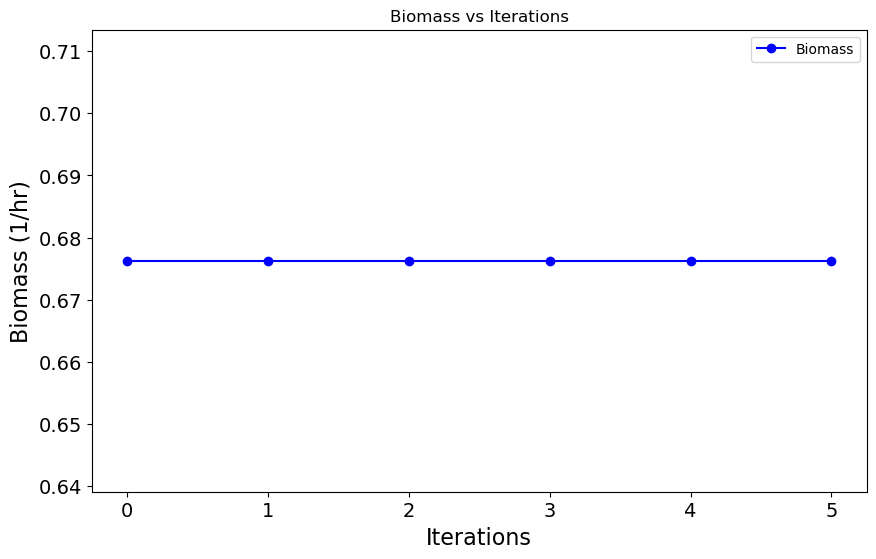

In [21]:
# === Configuration ===
organism_strain_GEMname = "ecoli_iML1515" # Update this
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}"
tuning_results_dir = os.path.join("../notebooks", "results", "tuning_results", run_id)

print("===Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.975
min_temperature = 0.001
max_iterations = 100
max_unchanged_iterations = 5
change_threshold = 0.009
biomass_goal = 0.87

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA_modified_tuned = simulated_annealing(
    model=mod_annotated_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict_modified,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top 10 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])

In [22]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_annotated_model.genes))
print("  Reactions in model:", len(mod_annotated_model.reactions))
model_gene_ids = set([g.id for g in mod_annotated_model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_annotated_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b3187', 'b0037', 'b3794', 'b3426', 'b3616', 'b3447', 'b2162', 'b4141', 'b1377', 'b2296']
  First 10 reaction IDs: ['SUCASPtpp', 'EX_ptrc_e', 'DADNt2pp', 'DHPPDA2', 'G6PP', 'EX_asn__L_e', 'DGK1', 'EX_glyclt_e', 'ALLTAMH2', 'XMPtex']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [23]:
out_path_modified_tuned = os.path.join("../notebooks", 
                        "results", 
                        "exp_validation_results", 
                        "W3110_MD121_M9+Glu_none", 
                        "df_FBA_modified_model_tuned.csv")

df_FBA_modified_tuned.to_csv(out_path_modified_tuned, index=False)

# Correlation to experimental fluxes

In [24]:
from kinGEMs.plots import plot_flux_correlation, plot_flux_differences

In [25]:
# Crown experiment
experiment = 'W3110_MD121_M9+Glu_none'
experimental_fluxes_path = os.path.join(experimental_data_dir, f"fluxes_{experiment}.csv")

### Regular

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


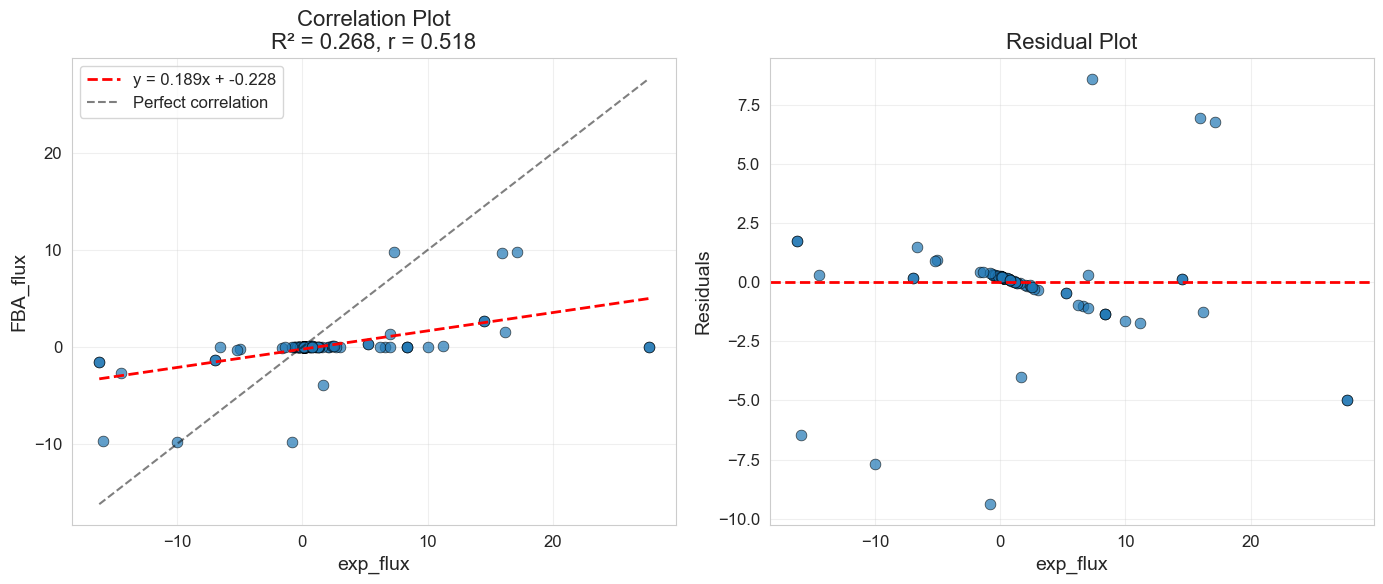

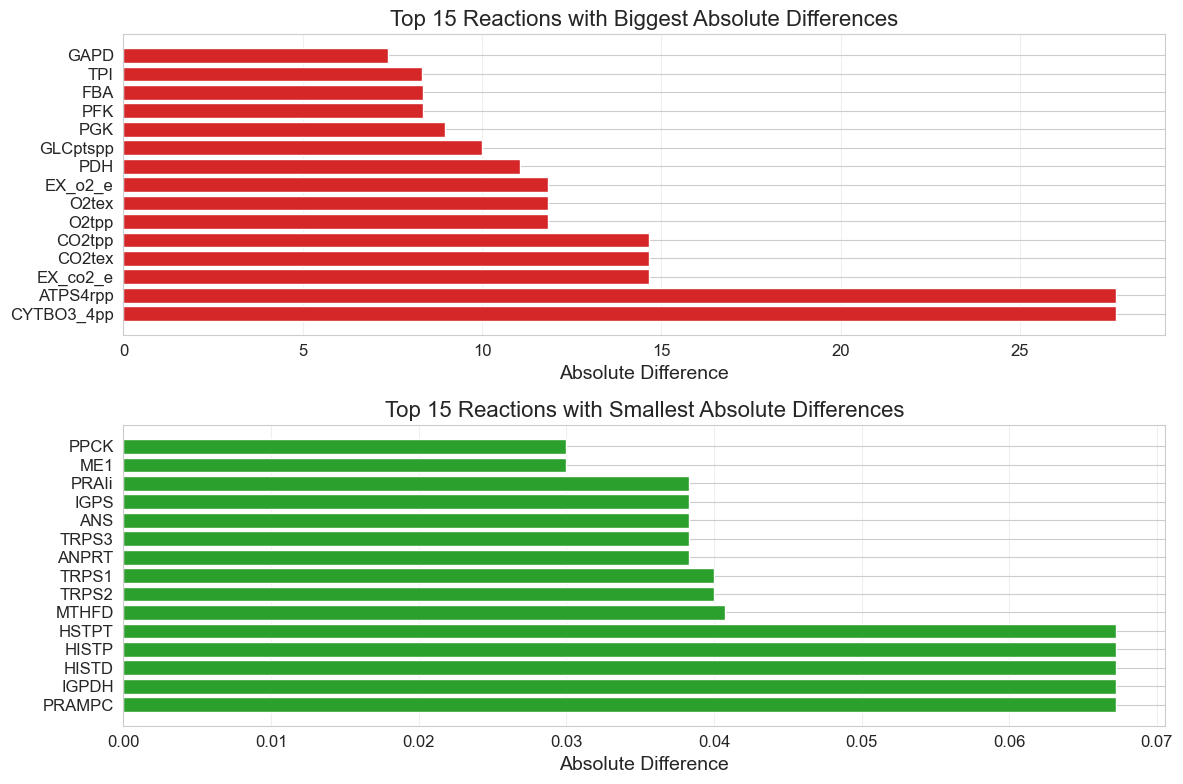

In [26]:
regular_exp_validation_df = compare_fluxomics(fba_results_path=out_path_regular, 
                                      exp_fluxes_path=experimental_fluxes_path)

# Correlation plot
fig, results = plot_flux_correlation(regular_exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(regular_exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

### Modified

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


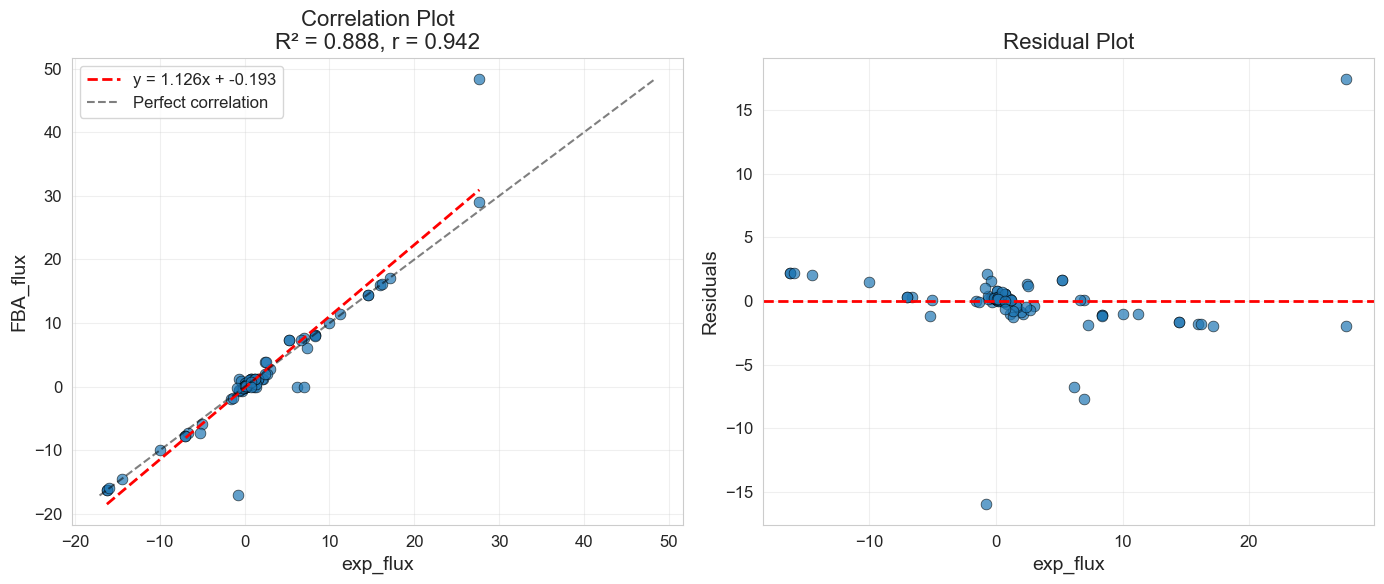

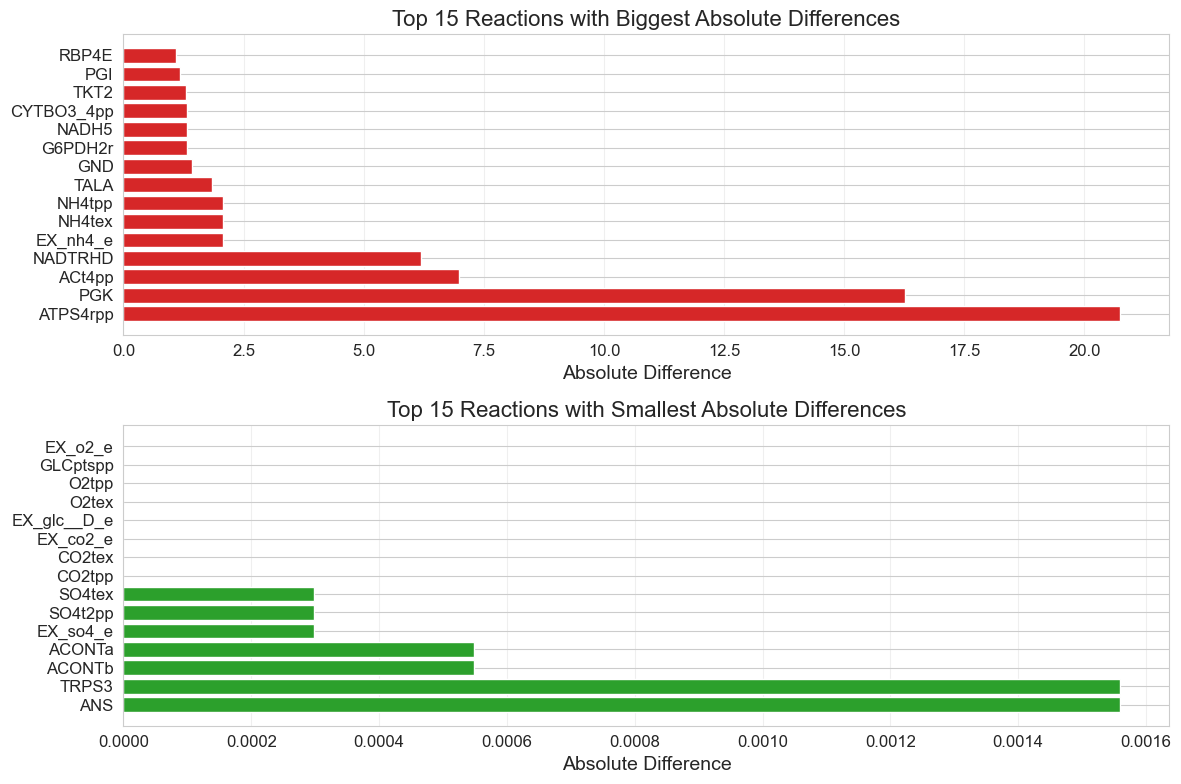

In [27]:
modified_exp_validation_df = compare_fluxomics(fba_results_path=out_path_modified, 
                                      exp_fluxes_path=experimental_fluxes_path)

# Correlation plot
fig, results = plot_flux_correlation(modified_exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(modified_exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

### Modified and tuned

In [28]:
df_mod_tuned = pd.read_csv(out_path_modified_tuned)

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


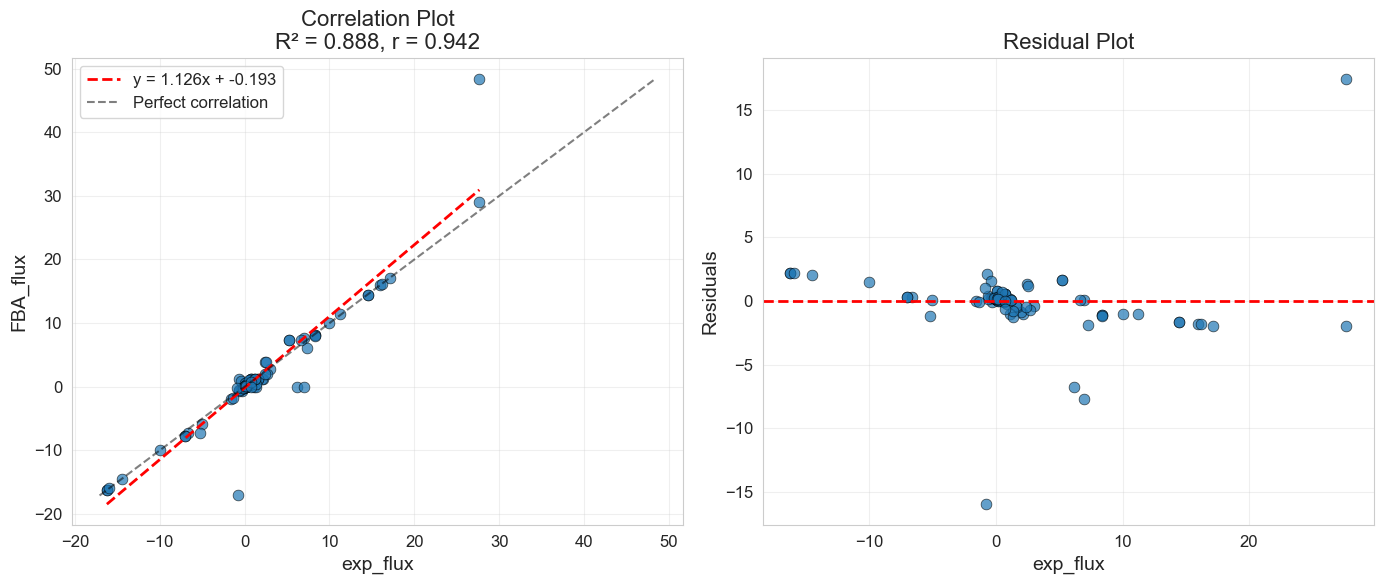

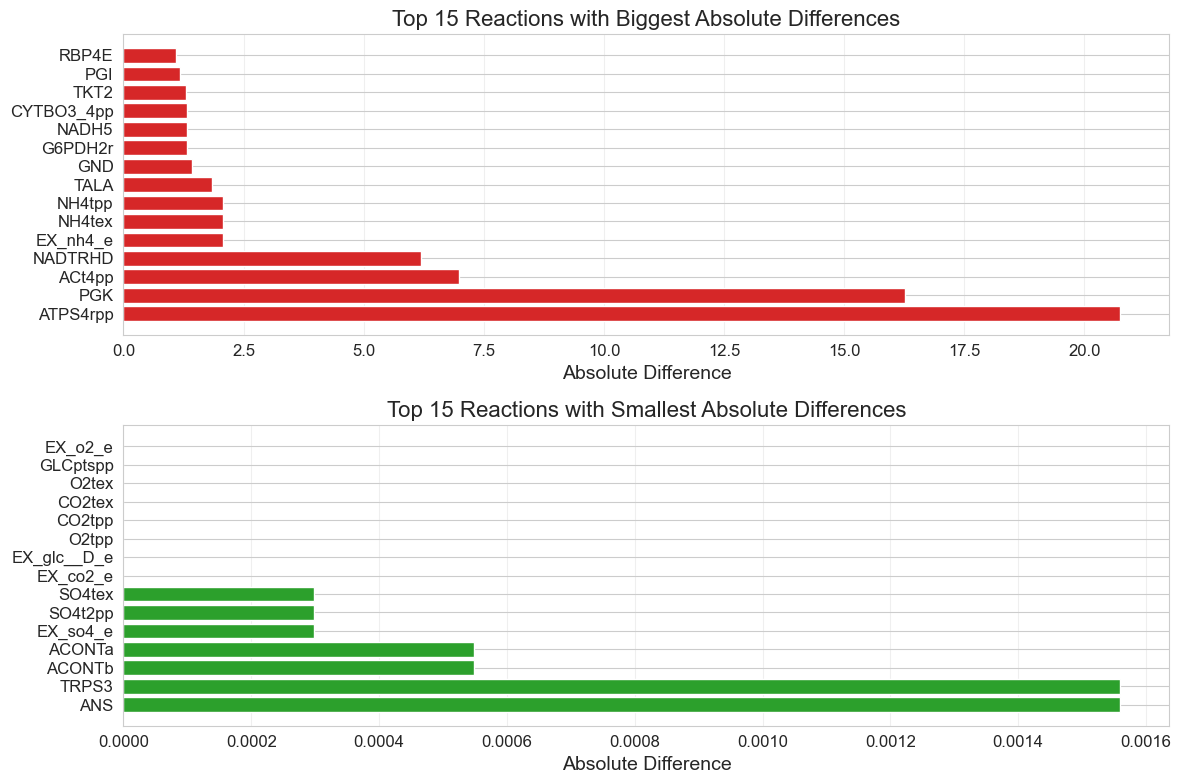

In [29]:
modified_tuned_exp_validation_df = compare_fluxomics(fba_results_path=out_path_modified_tuned, 
                                      exp_fluxes_path=experimental_fluxes_path)

# Correlation plot
fig, results = plot_flux_correlation(modified_tuned_exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(modified_tuned_exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

## Comparing kinGEMs fluxes against COBRApy

### kinGEMs vs FBA (both with modified media bounds)

Loaded 2712 kinGEMs fluxes
Loaded 2712 COBRApy FBA fluxes
Merged dataframe has 2712 rows
Matched reactions: 2712
Unmatched reactions: 0


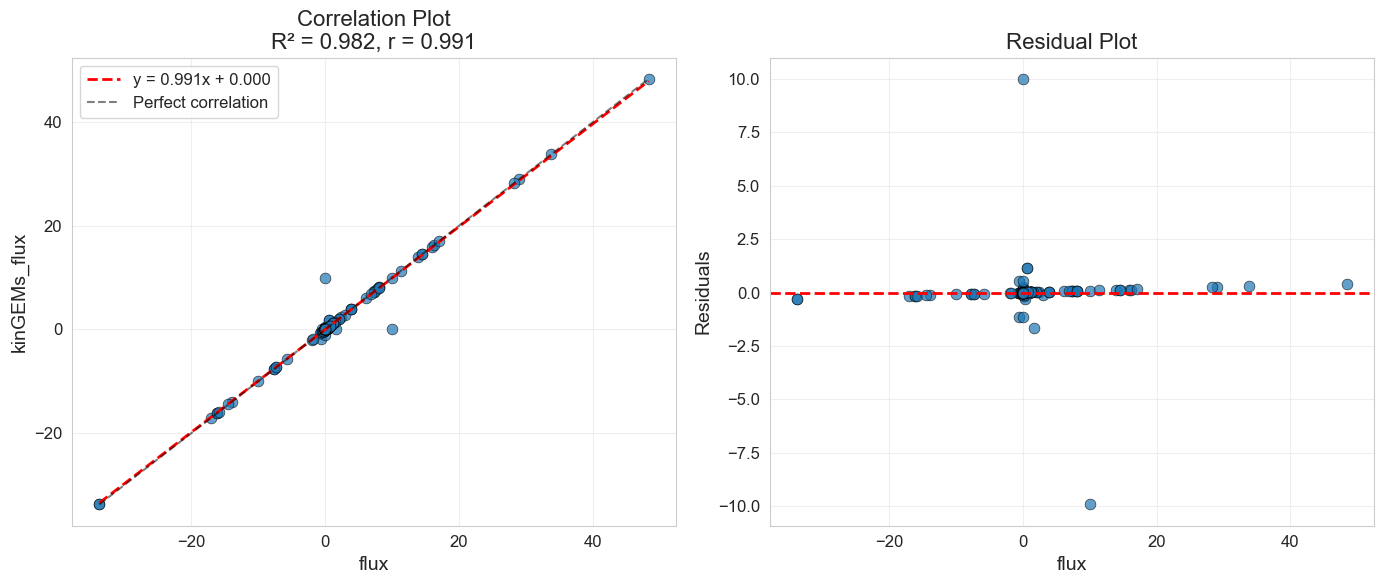

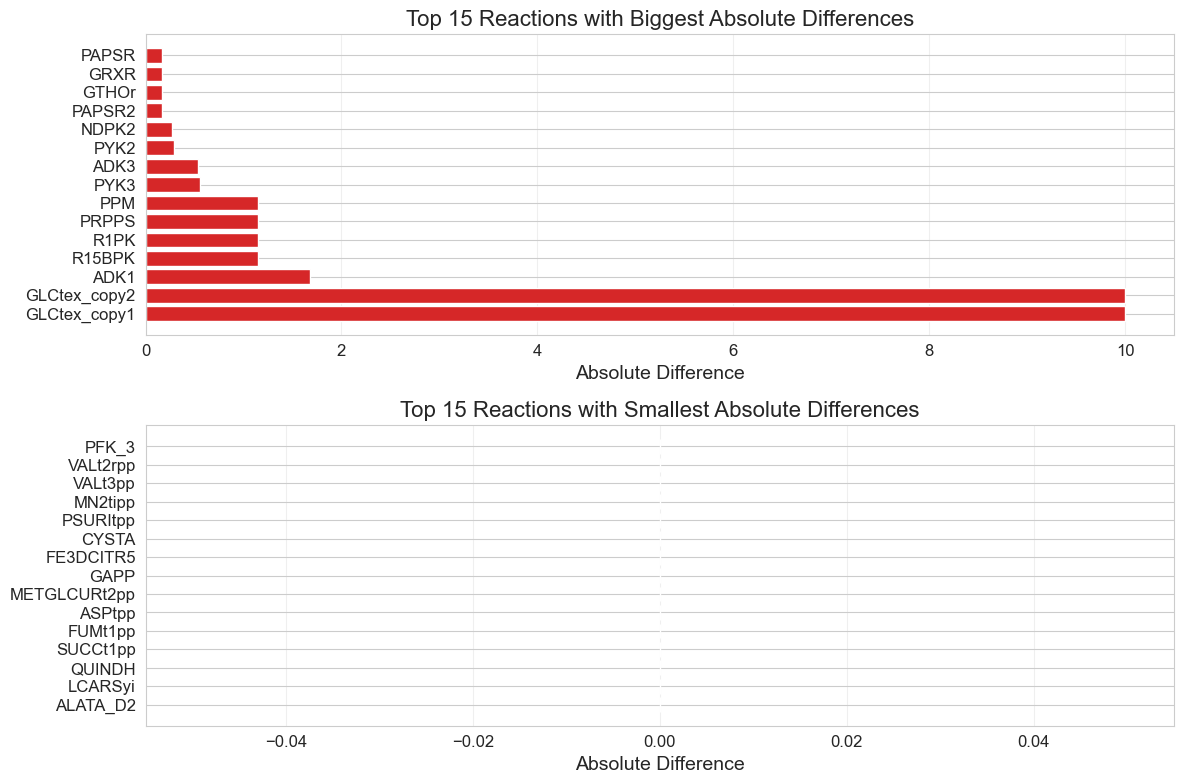

In [30]:
from kinGEMs.plots import kingems_cobrapy_dataframe

fba_path = os.path.join("../data", "cobrapy", "FBA.csv")
pfba_path = os.path.join("../data", "cobrapy", "pFBA.csv")

fba_kingems_df = kingems_cobrapy_dataframe(kingems_path=out_path_modified, fba_path=fba_path)

# Correlation plot
fig, results = plot_flux_correlation(fba_kingems_df, 'flux', 'kinGEMs_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(fba_kingems_df, 'flux', 'kinGEMs_flux', top_n=15, 
                                      difference_type='absolute', show=True)

### kinGEMs vs pFBA (both with modified media bounds)

Loaded 2712 kinGEMs fluxes
Loaded 2712 COBRApy FBA fluxes
Merged dataframe has 2712 rows
Matched reactions: 2712
Unmatched reactions: 0


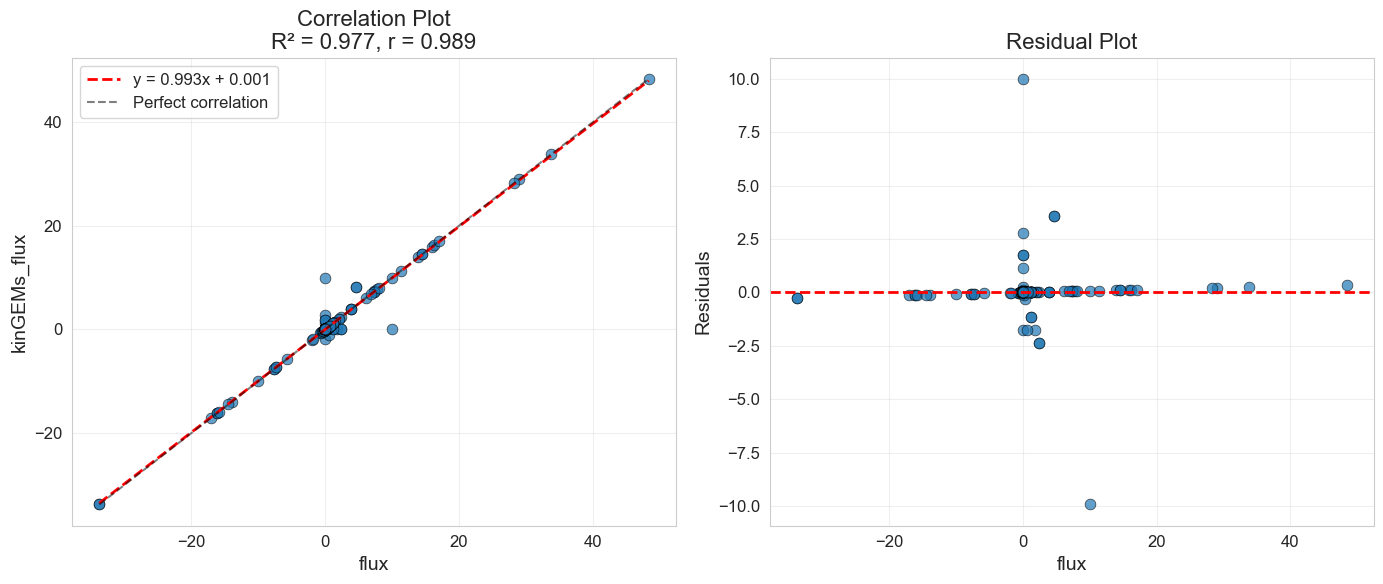

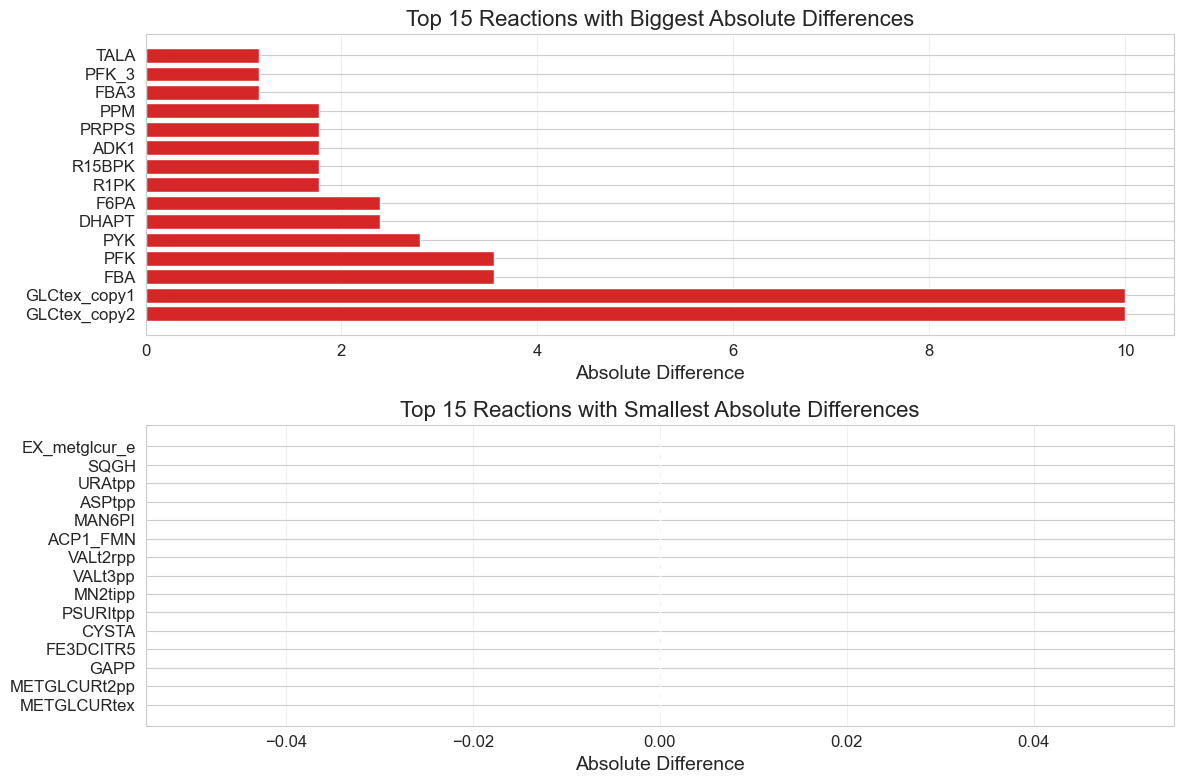

In [31]:
pfba_kingems_df = kingems_cobrapy_dataframe(kingems_path=out_path_modified, fba_path=pfba_path)

# Correlation plot
fig, results = plot_flux_correlation(pfba_kingems_df, 'flux', 'kinGEMs_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(pfba_kingems_df, 'flux', 'kinGEMs_flux', top_n=15, 
                                      difference_type='absolute', show=True)